# Treadmill Buyer Profile Analysis

## Table of Contents

1. [Imports and Data Loading](#1-imports-and-data-loading)
2. [Data Validation and Schema Hygiene](#2-data-validation-and-schema-hygiene)
3. [Feature Engineering for Business-Friendly Segments](#3-feature-engineering-for-business-friendly-segments)
4. [Non-Visual Analysis - Statistical Summary](#4-non-visual-analysis---statistical-summary)
5. [Visual Analysis - Univariate](#5-visual-analysis---univariate)
6. [Visual Analysis - Bivariate](#6-visual-analysis---bivariate)
7. [Visual Analysis - Multivariate](#7-visual-analysis---multivariate)
8. [Correlation Analysis](#8-correlation-analysis)
9. [Outlier Detection](#9-outlier-detection)
10. [Product-Level Customer Profiles](#10-product-level-customer-profiles)
11. [Generating Two-Way Contingency Tables and Conditional Probabilities](#11-generating-two-way-contingency-tables-and-conditional-probabilities)
12. [High-Impact Recommendation Signals](#12-high-impact-recommendation-signals)
13. [Insights and Business Recommendations](#13-insights-and-business-recommendations)

## 1. Imports and Data Loading

Assumes `aerofit_treadmill_data.csv` in the same folder as this notebook

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


df_raw = pd.read_csv('aerofit_treadmill_data.csv')
print(f"Shape: {df_raw.shape}")
df_raw.head()

Shape: (180, 9)


,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


## 2. Data Validation and Schema Hygiene

These checks validate against silent data-quality problems such as missing product labels, duplicate rows, or unexpected columns.

In [2]:
EXPECTED_COLUMNS = [
    "Product", "Age", "Gender", "Education", "MaritalStatus",
    "Usage", "Fitness", "Income", "Miles"
]


'''
Product:	Product purchased - KP281, KP481, or KP781
Age:  Age of the customer in years
Gender:	Gender of the customer: male or female
Education:	Education of the customer in years
MaritalStatus:	Marital status of the customer: single or partnered
Usage:	Average number of times the customer plans to use the treadmill each week
Fitness:	Self-rated fitness on a 1-5 scale, where 1 is poor shape and 5 is excellent shape
Income:	Annual income of the customer in US dollars
Miles:	Average number of miles the customer expects to walk or run each week
'''


def validate_and_prepare(data: pd.DataFrame) -> pd.DataFrame:
    """Clean column names, validate expected schema, and optimize categorical columns."""
    df = data.copy()
    df.columns = df.columns.str.strip()

    missing_cols = sorted(set(EXPECTED_COLUMNS) - set(df.columns))
    extra_cols = sorted(set(df.columns) - set(EXPECTED_COLUMNS))

    if missing_cols:
        raise ValueError(f"Missing expected columns: {missing_cols}")
    if extra_cols:
        print(f"Note: extra columns found and retained: {extra_cols}")

    df = df[EXPECTED_COLUMNS]

    categorical_cols = ["Product", "Gender", "MaritalStatus"]
    for col in categorical_cols:
        df[col] = df[col].astype("category")

    return df


df = validate_and_prepare(df_raw)

quality_summary = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_pct": df.isna().mean().mul(100).round(2),
    "n_unique": df.nunique(dropna=False),
})

display(quality_summary)
print(f"\nDuplicate rows: {df.duplicated().sum()}")

,dtype,missing_count,missing_pct,n_unique
Product,category,0,0.00,3
Age,int64,0,0.00,32
Gender,category,0,0.00,2
Education,int64,0,0.00,8
MaritalStatus,category,0,0.00,2
Usage,int64,0,0.00,6
Fitness,int64,0,0.00,5
Income,int64,0,0.00,62
Miles,int64,0,0.00,37



Duplicate rows: 0


## 3. Feature Engineering for Business-Friendly Segments

Binning certain features for better usage, but implemented safely with explicit lower/upper coverage so no minimum or maximum value is accidentally dropped.

In [3]:
def add_customer_segments(data: pd.DataFrame) -> pd.DataFrame:
    """Add interpretable customer bands used in crosstabs and recommendations."""
    df = data.copy()

    df["Age_Group"] = pd.cut(
        df["Age"],
        bins=[17, 20, 25, 30, 35, 40, 51],
        labels=["18-20", "21-25", "26-30", "31-35", "36-40", "41-50"],
        include_lowest=True,
        right=True,
    )

    df["Income_Group"] = pd.cut(
        df["Income"],
        bins=[0, 35_000, 45_000, 60_000, 85_000, np.inf],
        labels=["<35k", "35k-45k", "45k-60k", "60k-85k", "85k+"],
        include_lowest=True,
        right=False,
    )

    df["Miles_Group"] = pd.cut(
        df["Miles"],
        bins=[0, 50, 100, 150, 200, np.inf],
        labels=["<50", "50-99", "100-149", "150-199", "200+"],
        include_lowest=True,
        right=False,
    )

    df["Education_Group"] = pd.cut(
        df["Education"],
        bins=[0, 14, 16, 18, np.inf],
        labels=["<=14", "15-16", "17-18", "19+"],
        include_lowest=True,
        right=True,
    )

    return df


analysis_df = add_customer_segments(df)

segment_cols = ["Age_Group", "Income_Group", "Miles_Group", "Education_Group"]
display(analysis_df.head())
display(analysis_df[segment_cols].isna().sum().to_frame("missing_after_binning"))

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles,Age_Group,Income_Group,Miles_Group,Education_Group
0,KP281,18,Male,14,Single,3,4,29562,112,18-20,<35k,100-149,<=14
1,KP281,19,Male,15,Single,2,3,31836,75,18-20,<35k,50-99,15-16
2,KP281,19,Female,14,Partnered,4,3,30699,66,18-20,<35k,50-99,<=14
3,KP281,19,Male,12,Single,3,3,32973,85,18-20,<35k,50-99,<=14
4,KP281,20,Male,13,Partnered,4,2,35247,47,18-20,35k-45k,<50,<=14


,missing_after_binning
Age_Group,0
Income_Group,0
Miles_Group,0
Education_Group,0


## 4. Non-Visual Analysis - Statistical Summary

In [4]:
numeric_cols = ["Age", "Education", "Usage", "Fitness", "Income", "Miles"]
categorical_cols = ["Product", "Gender", "MaritalStatus"]

print("Numeric summary")
display(df[numeric_cols].describe().T)

print("\nSkewness")
display(df[numeric_cols].skew().sort_values(ascending=False).to_frame("skewness"))

print("\nCategorical distributions")
for col in categorical_cols:
    display(
        df[col]
        .value_counts(dropna=False)
        .to_frame("count")
        .assign(percent=lambda x: (x["count"] / len(df) * 100).round(2))
    )

Numeric summary


,count,mean,std,min,25%,50%,75%,max
Age,180.00,28.79,6.94,18.00,24.00,26.00,33.00,50.00
Education,180.00,15.57,1.62,12.00,14.00,16.00,16.00,21.00
Usage,180.00,3.46,1.08,2.00,3.00,3.00,4.00,7.00
Fitness,180.00,3.31,0.96,1.00,3.00,3.00,4.00,5.00
Income,180.00,"53,719.58","16,506.68","29,562.00","44,058.75","50,596.50","58,668.00","104,581.00"
Miles,180.00,103.19,51.86,21.00,66.00,94.00,114.75,360.00



Skewness


,skewness
Miles,1.72
Income,1.29
Age,0.98
Usage,0.74
Education,0.62
Fitness,0.45



Categorical distributions


,count,percent
Product,,
KP281,80,44.44
KP481,60,33.33
KP781,40,22.22


,count,percent
Gender,,
Male,104,57.78
Female,76,42.22


,count,percent
MaritalStatus,,
Partnered,107,59.44
Single,73,40.56


## 5. Visual Analysis - Univariate

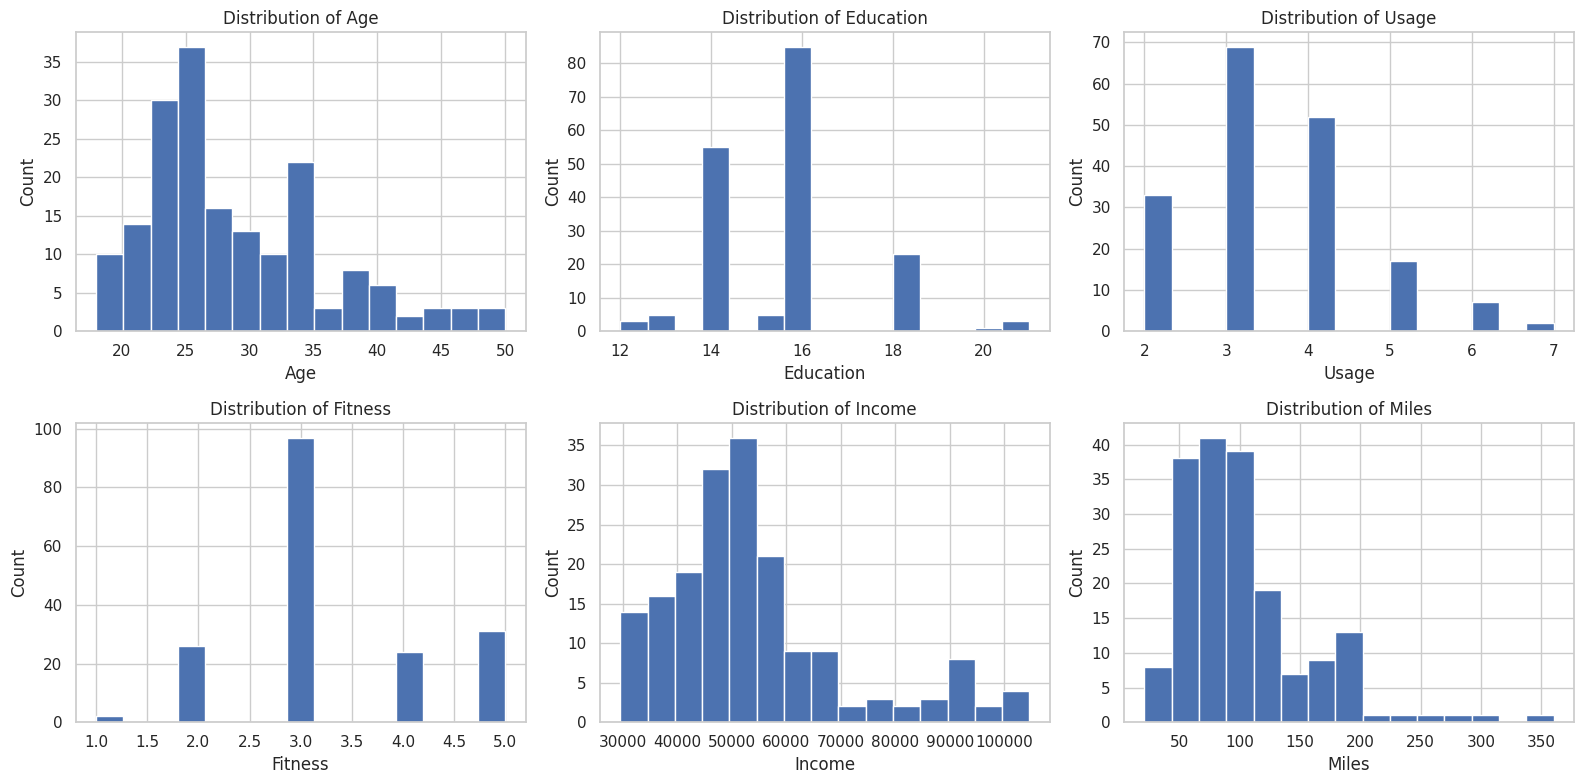

In [5]:
# Univariate distributions for numerical variables
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    ax.hist(analysis_df[col].dropna(), bins=15)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

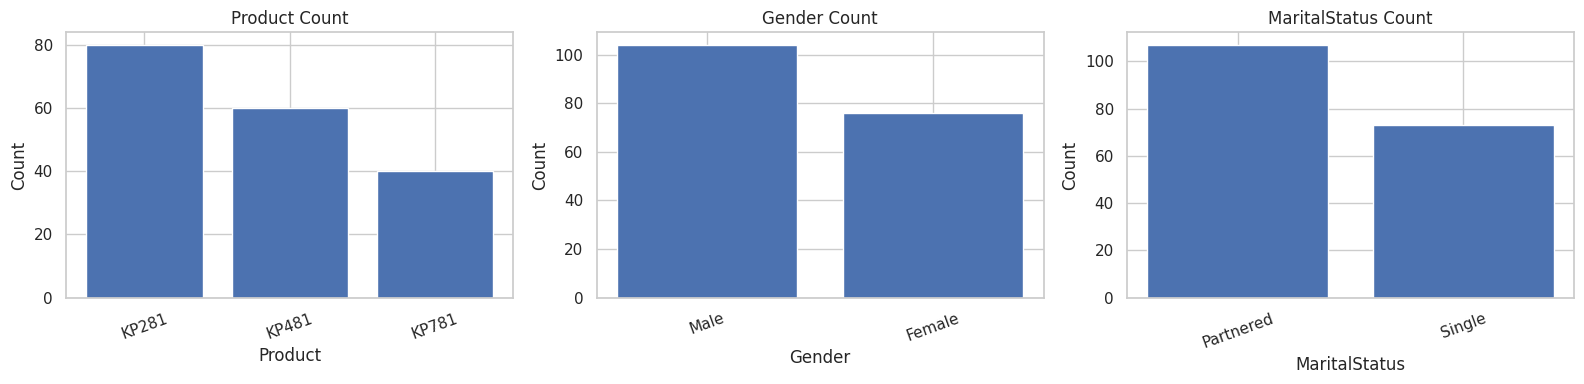

In [6]:
# Product and customer-category counts
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, categorical_cols):
    counts = analysis_df[col].value_counts()
    ax.bar(counts.index.astype(str), counts.values)
    ax.set_title(f"{col} Count")
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

## 6. Visual Analysis - Bivariate

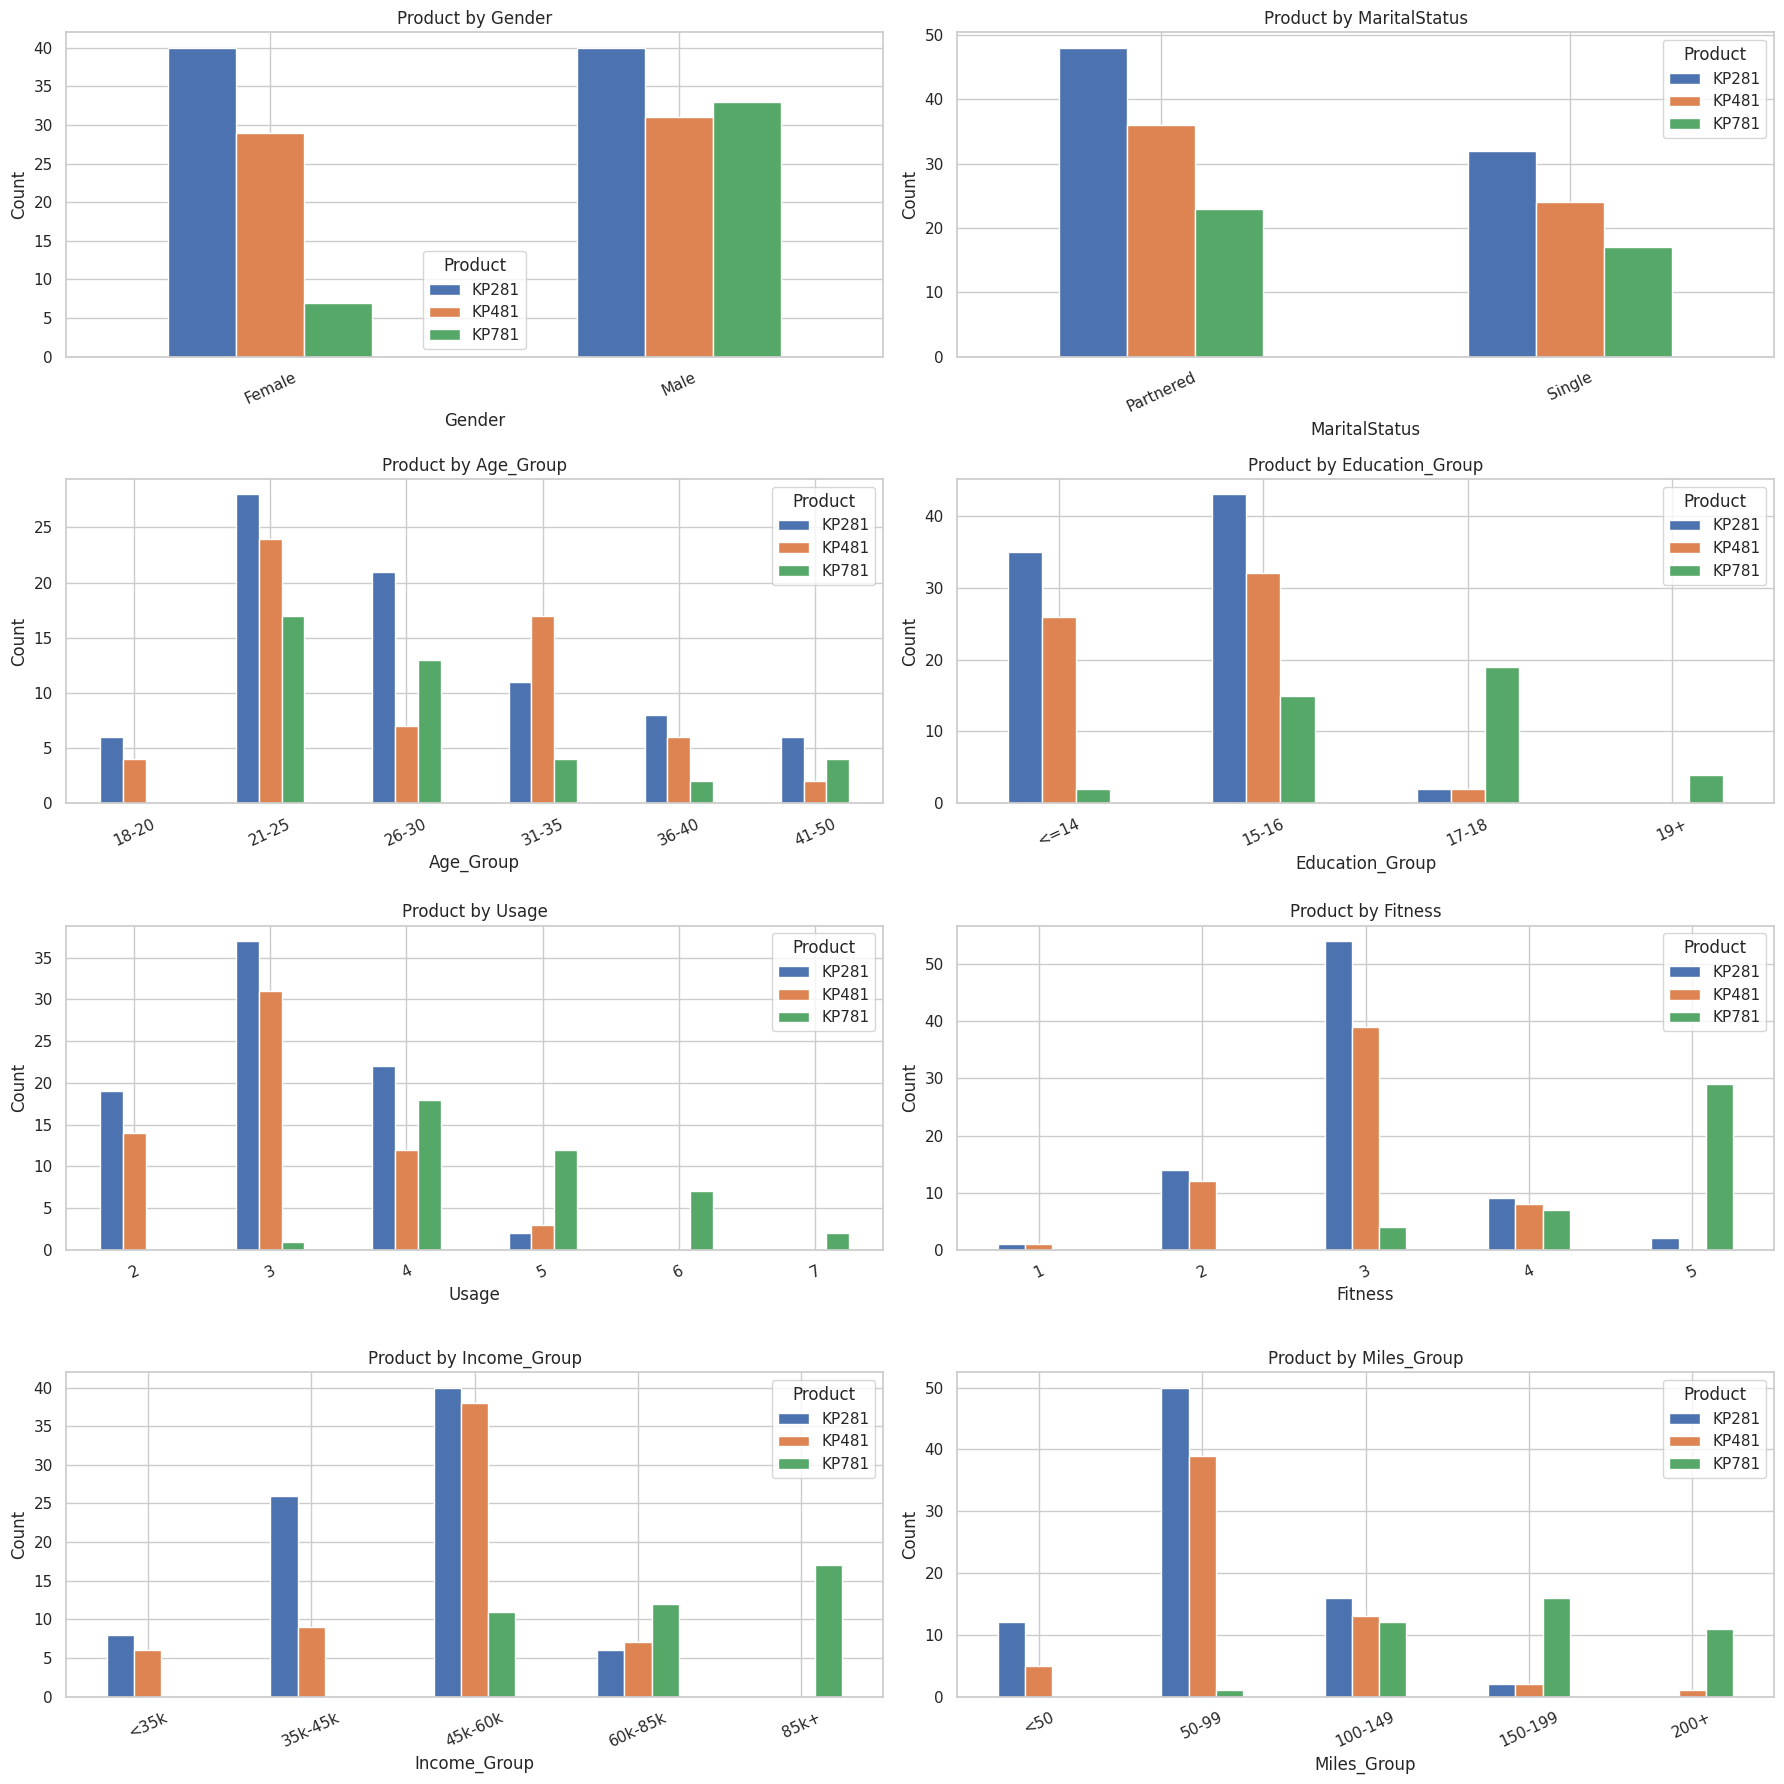

In [7]:
# Product vs categorical / binned features
plot_features = ["Gender", "MaritalStatus", "Age_Group", "Education_Group", "Usage", "Fitness", "Income_Group", "Miles_Group"]
fig, axes = plt.subplots(4, 2, figsize=(18, 18))
axes = axes.flatten()

for ax, feature in zip(axes, plot_features):
    plot_table = pd.crosstab(analysis_df[feature], analysis_df["Product"])
    plot_table.plot(kind="bar", ax=ax)
    ax.set_title(f"Product by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=25)
    ax.legend(title="Product")

plt.tight_layout()
plt.show()

## 7. Visual Analysis - Multivariate

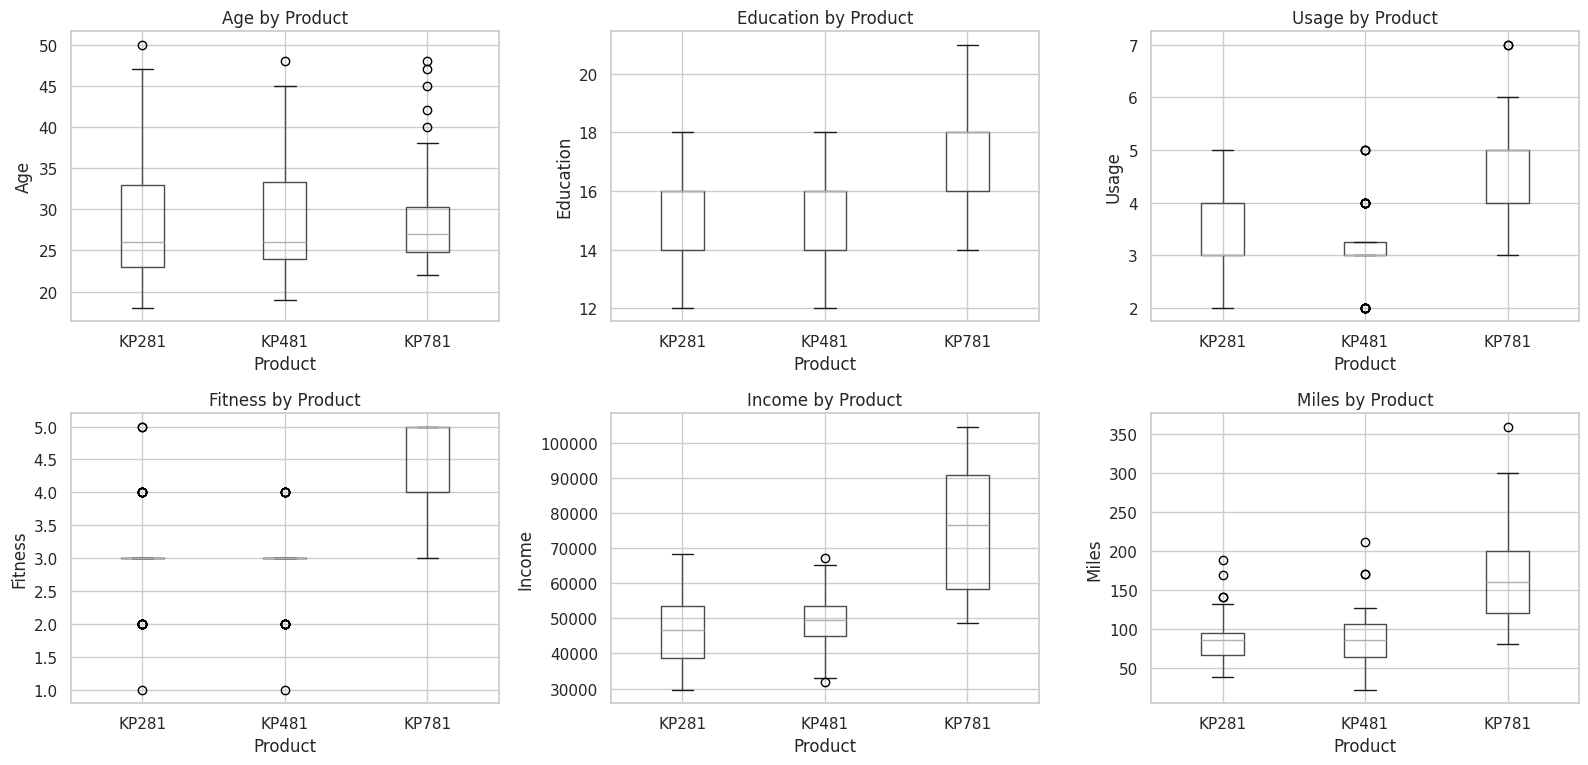

In [8]:
# Product vs numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    analysis_df.boxplot(column=col, by="Product", ax=ax)
    ax.set_title(f"{col} by Product")
    ax.set_xlabel("Product")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()
plt.show()

## 8. Correlation Analysis

Correlation helps explain why premium-product buyers cluster around higher fitness, higher weekly usage, and higher expected mileage.

,Age,Education,Usage,Fitness,Income,Miles
Age,1.00,0.28,0.01,0.06,0.51,0.04
Education,0.28,1.00,0.40,0.41,0.63,0.31
Usage,0.01,0.40,1.00,0.67,0.52,0.76
Fitness,0.06,0.41,0.67,1.00,0.54,0.79
Income,0.51,0.63,0.52,0.54,1.00,0.54
Miles,0.04,0.31,0.76,0.79,0.54,1.00


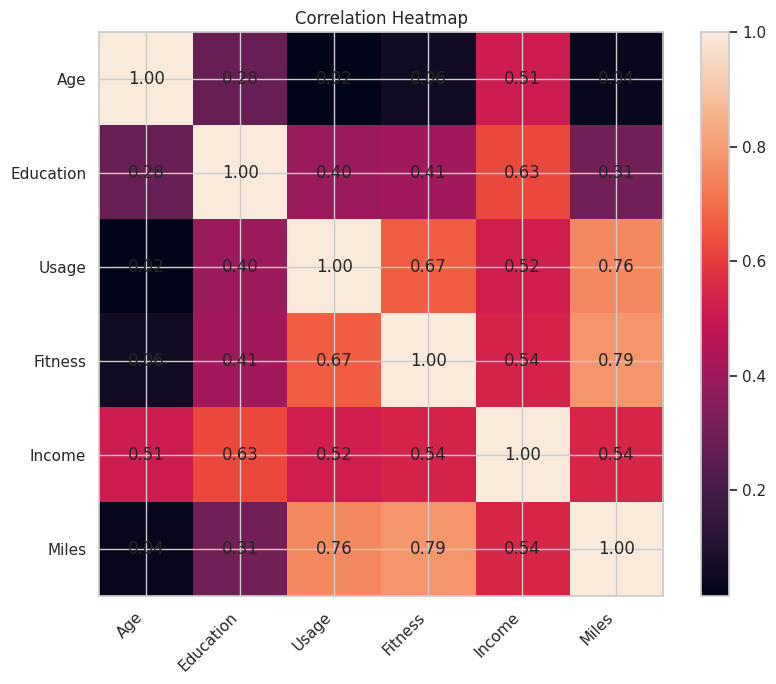

In [9]:
corr = analysis_df[numeric_cols].corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(corr.values)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

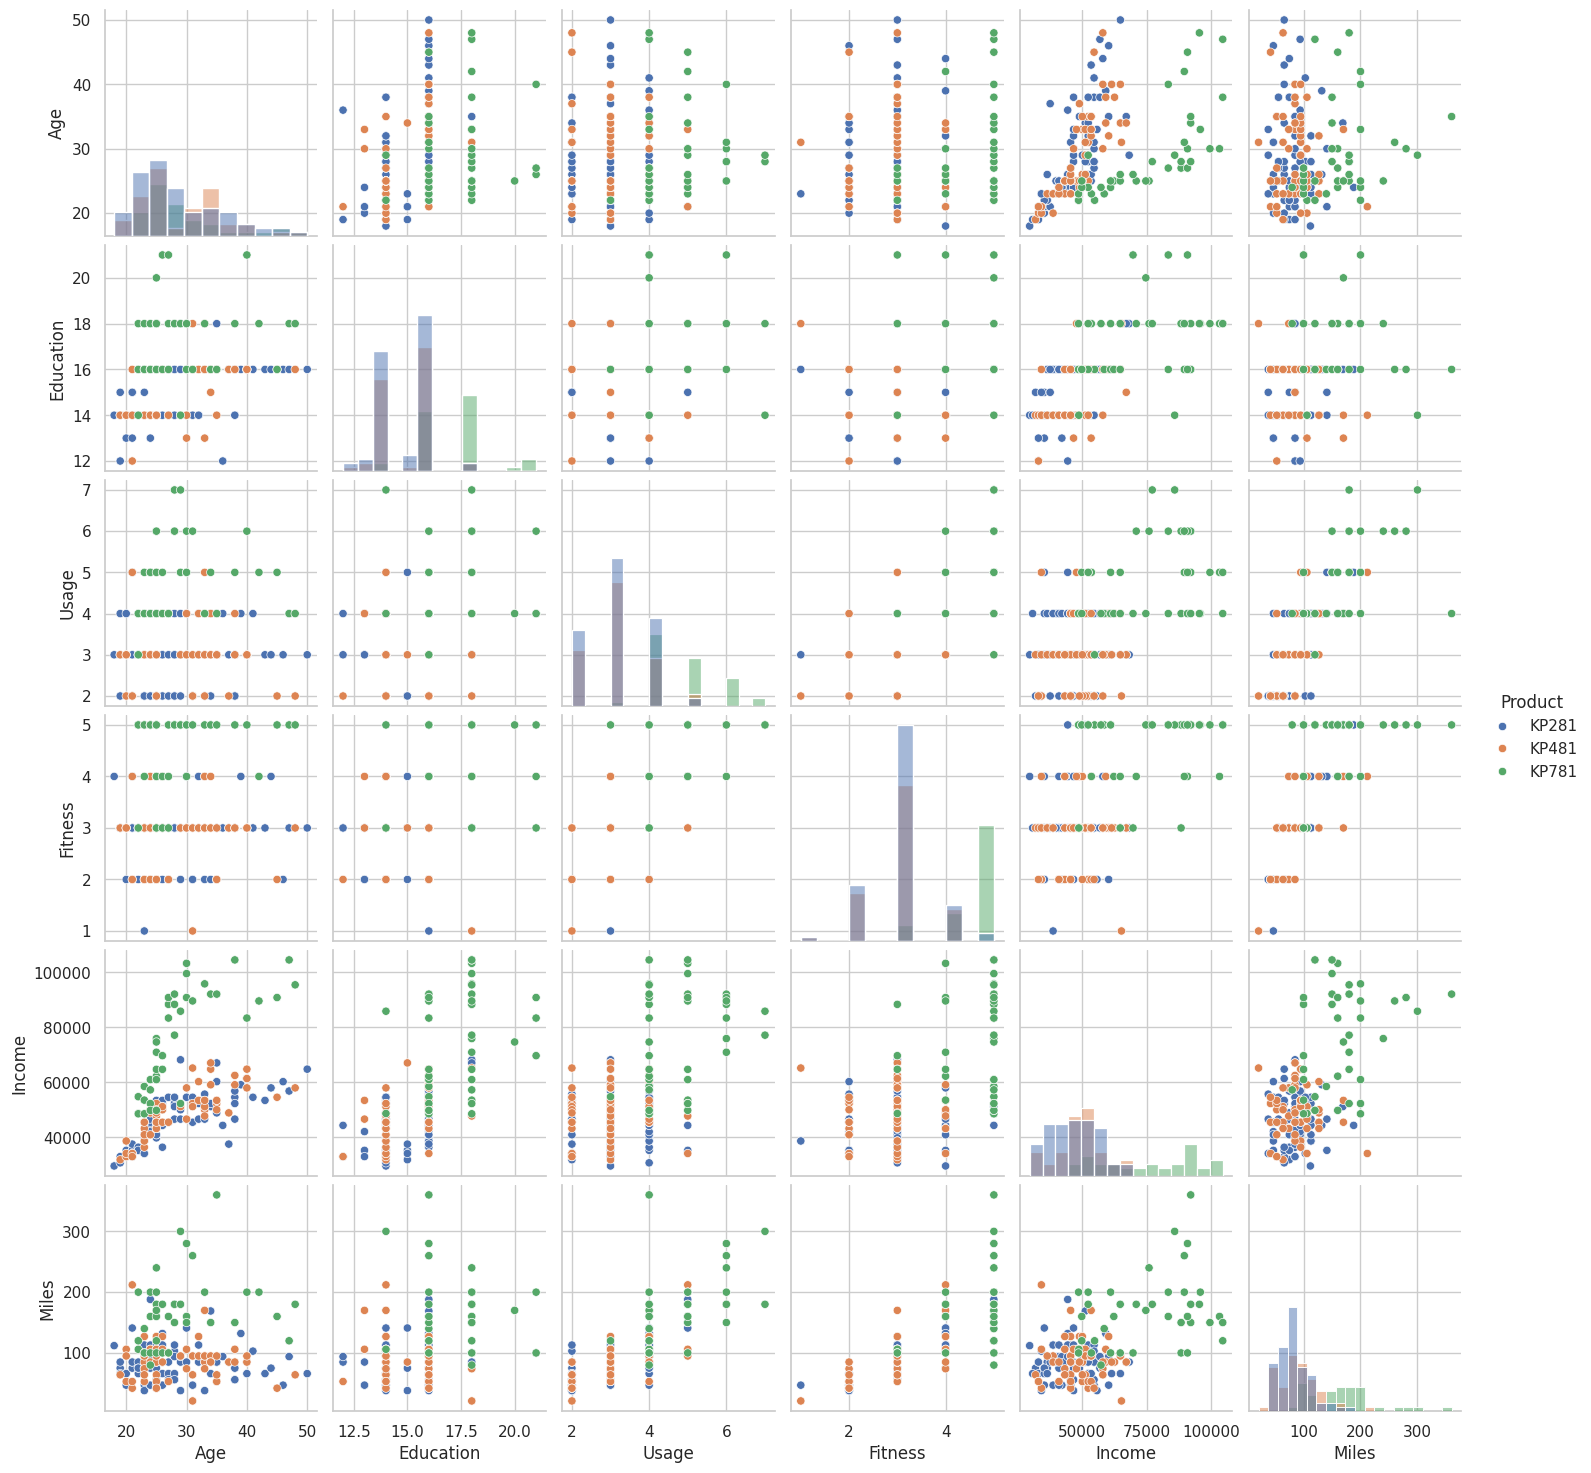

In [10]:
# Optional but useful multivariate view for a small dataset.
RUN_PAIRPLOT = True

if RUN_PAIRPLOT:
    sns.pairplot(analysis_df, vars=numeric_cols, hue="Product", diag_kind="hist")
    plt.show()

## 9. Outlier Detection

Outliers are quantified but retained. In this business problem, high Income and high Miles observations are meaningful premium-product signals, not automatic data errors.

In [11]:
def iqr_bounds(series: pd.Series) -> tuple[float, float]:
    """Return lower and upper IQR outlier bounds."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


outlier_summary_rows = []
outlier_flag_df = analysis_df.copy()

for col in numeric_cols:
    lower, upper = iqr_bounds(outlier_flag_df[col])
    flag_col = f"{col}_Outlier"
    outlier_flag_df[flag_col] = (outlier_flag_df[col] < lower) | (outlier_flag_df[col] > upper)
    outlier_summary_rows.append({
        "Feature": col,
        "Lower_Bound": round(lower, 2),
        "Upper_Bound": round(upper, 2),
        "Outlier_Count": int(outlier_flag_df[flag_col].sum()),
        "Outlier_%": round(outlier_flag_df[flag_col].mean() * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary_rows)
display(outlier_summary)

outlier_cols = [f"{col}_Outlier" for col in numeric_cols]
outliers_by_product = (
    outlier_flag_df
    .groupby("Product", observed=True)[outlier_cols]
    .mean()
    .mul(100)
    .round(2)
)

display(outliers_by_product)

,Feature,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_%
0,Age,10.50,46.50,5,2.78
1,Education,11.00,19.00,4,2.22
2,Usage,1.50,5.50,9,5.00
3,Fitness,1.50,5.50,2,1.11
4,Income,"22,144.88","80,581.88",19,10.56
5,Miles,-7.12,187.88,13,7.22


,Age_Outlier,Education_Outlier,Usage_Outlier,Fitness_Outlier,Income_Outlier,Miles_Outlier
Product,,,,,,
KP281,2.50,0.00,0.00,1.25,0.00,1.25
KP481,1.67,0.00,0.00,1.67,0.00,1.67
KP781,5.00,10.00,22.50,0.00,47.50,27.50


## 10. Product-Level Customer Profiles

This is the core customer-profile table: it summarizes who buys each treadmill and the median/mean behavior associated with each product.

In [12]:
product_summary = (
    analysis_df
    .groupby("Product", observed=True)
    .agg(
        Customers=("Product", "size"),
        Median_Age=("Age", "median"),
        Mean_Age=("Age", "mean"),
        Median_Education=("Education", "median"),
        Median_Usage=("Usage", "median"),
        Median_Fitness=("Fitness", "median"),
        Median_Income=("Income", "median"),
        Mean_Income=("Income", "mean"),
        Median_Miles=("Miles", "median"),
        Mean_Miles=("Miles", "mean"),
    )
)
product_summary.insert(1, "Sales_Share_%", (product_summary["Customers"] / len(analysis_df) * 100).round(2))

display(product_summary.round(2))

,Customers,Sales_Share_%,Median_Age,Mean_Age,Median_Education,Median_Usage,Median_Fitness,Median_Income,Mean_Income,Median_Miles,Mean_Miles
Product,,,,,,,,,,,
KP281,80,44.44,26.00,28.55,16.00,3.00,3.00,"46,617.00","46,418.02",85.00,82.79
KP481,60,33.33,26.00,28.90,16.00,3.00,3.00,"49,459.50","48,973.65",85.00,87.93
KP781,40,22.22,27.00,29.10,18.00,5.00,5.00,"76,568.50","75,441.58",160.00,166.90


In [13]:
def top_segment_by_product(data: pd.DataFrame, features: list[str], target: str = "Product") -> pd.DataFrame:
    """Return the dominant segment for each product-feature pair."""
    rows = []
    for product, product_df in data.groupby(target, observed=True):
        for feature in features:
            dist = product_df[feature].value_counts(normalize=True, dropna=False).mul(100)
            top_value = dist.index[0]
            rows.append({
                "Product": product,
                "Feature": feature,
                "Top Segment": top_value,
                "Within Product %": round(dist.iloc[0], 2),
            })
    return pd.DataFrame(rows)


profile_features = ["Gender", "MaritalStatus", "Age_Group", "Education_Group", "Usage", "Fitness", "Income_Group", "Miles_Group"]
display(top_segment_by_product(analysis_df, profile_features))

,Product,Feature,Top Segment,Within Product %
0,KP281,Gender,Female,50.00
1,KP281,MaritalStatus,Partnered,60.00
2,KP281,Age_Group,21-25,35.00
3,KP281,Education_Group,15-16,53.75
4,KP281,Usage,3,46.25
5,KP281,Fitness,3,67.50
6,KP281,Income_Group,45k-60k,50.00
7,KP281,Miles_Group,50-99,62.50
8,KP481,Gender,Male,51.67
9,KP481,MaritalStatus,Partnered,60.00


## 11. Generating Two-Way Contingency Tables and Conditional Probabilities

For every feature below, the function returns:

- **Counts:** raw two-way contingency table with margins
- **Row %:** `P(feature segment | Product)` — useful for profiling each product's buyers
- **Column %:** `P(Product | feature segment)` — useful for recommending a product to a new customer segment
- **Joint %:** `P(Product and feature segment)` — share of total customers in each combination
- **Marginal %:** standalone probabilities for product and feature segments

In [14]:
def probability_tables(data: pd.DataFrame, feature: str, target: str = "Product", decimals: int = 2) -> dict[str, pd.DataFrame]:
    """Build count, marginal, joint, and conditional probability tables for a feature vs. target."""
    counts = pd.crosstab(data[target], data[feature], margins=True, dropna=False)

    row_pct = (
        pd.crosstab(data[target], data[feature], normalize="index", dropna=False)
        .mul(100)
        .round(decimals)
    )
    row_pct.index.name = f"{target} → P({feature} | {target})"

    col_pct = (
        pd.crosstab(data[target], data[feature], normalize="columns", dropna=False)
        .mul(100)
        .round(decimals)
    )
    col_pct.index.name = f"{target} → P({target} | {feature})"

    joint_pct = (
        pd.crosstab(data[target], data[feature], normalize="all", dropna=False)
        .mul(100)
        .round(decimals)
    )
    joint_pct.index.name = f"{target} → P({target} and {feature})"

    feature_marginal = (
        data[feature]
        .value_counts(normalize=True, dropna=False)
        .mul(100)
        .round(decimals)
        .rename(f"{feature}_Marginal_%")
        .to_frame()
    )

    return {
        "counts": counts,
        "row_pct": row_pct,
        "col_pct": col_pct,
        "joint_pct": joint_pct,
        "feature_marginal": feature_marginal,
    }


def show_probability_analysis(data: pd.DataFrame, feature: str, target: str = "Product") -> None:
    """Display all probability tables for a selected feature."""
    tables = probability_tables(data, feature=feature, target=target)
    print(f"\n-----------------------------------\nFEATURE: {feature}")
    print("Counts")
    display(tables["counts"])
    print(f"Row %: P({feature} | {target})")
    display(tables["row_pct"])
    print(f"Column %: P({target} | {feature})")
    display(tables["col_pct"])
    print(f"Joint %: P({target} and {feature})")
    display(tables["joint_pct"])
    print("Marginal probabilities")
    display(tables["feature_marginal"])

In [15]:
features_for_probability_analysis = [
    "Gender",
    "MaritalStatus",
    "Age_Group",
    "Education_Group",
    "Usage",
    "Fitness",
    "Income_Group",
    "Miles_Group",
]

for feature in features_for_probability_analysis:
    show_probability_analysis(analysis_df, feature)


-----------------------------------
FEATURE: Gender
Counts


Gender,Female,Male,All
Product,,,
KP281,40,40,80
KP481,29,31,60
KP781,7,33,40
All,76,104,180


Row %: P(Gender | Product)


Gender,Female,Male
Product → P(Gender | Product),,
KP281,50.00,50.00
KP481,48.33,51.67
KP781,17.50,82.50


Column %: P(Product | Gender)


...

Miles_Group,<50,50-99,100-149,150-199,200+
Product → P(Product | Miles_Group),,,,,
KP281,70.59,55.56,39.02,10.00,0.00
KP481,29.41,43.33,31.71,10.00,8.33
KP781,0.00,1.11,29.27,80.00,91.67


Joint %: P(Product and Miles_Group)


Miles_Group,<50,50-99,100-149,150-199,200+
Product → P(Product and Miles_Group),,,,,
KP281,6.67,27.78,8.89,1.11,0.00
KP481,2.78,21.67,7.22,1.11,0.56
KP781,0.00,0.56,6.67,8.89,6.11


Marginal probabilities


,Miles_Group_Marginal_%
Miles_Group,
50-99,50.00
100-149,22.78
150-199,11.11
<50,9.44
200+,6.67


## 12. High-Impact Recommendation Signals

This table focuses on `P(Product | segment)`, which is the most directly useful probability direction when recommending a treadmill to a new customer.

In [16]:
def recommendation_signal_table(data: pd.DataFrame, features: list[str], target: str = "Product") -> pd.DataFrame:
    """Flatten P(Product | feature segment) tables into one recommendation-friendly table."""
    rows = []
    for feature in features:
        col_pct = probability_tables(data, feature=feature, target=target)["col_pct"]
        counts = pd.crosstab(data[target], data[feature], dropna=False)
        segment_totals = counts.sum(axis=0)

        for segment in col_pct.columns:
            best_product = col_pct[segment].idxmax()
            rows.append({
                "Feature": feature,
                "Segment": segment,
                "Segment_N": int(segment_totals[segment]),
                "Best_Product_By_Probability": best_product,
                "P_Best_Product_Given_Segment_%": float(col_pct.loc[best_product, segment]),
                "KP281_%": float(col_pct.loc["KP281", segment]) if "KP281" in col_pct.index else np.nan,
                "KP481_%": float(col_pct.loc["KP481", segment]) if "KP481" in col_pct.index else np.nan,
                "KP781_%": float(col_pct.loc["KP781", segment]) if "KP781" in col_pct.index else np.nan,
            })

    return pd.DataFrame(rows).sort_values(
        ["P_Best_Product_Given_Segment_%", "Segment_N"],
        ascending=[False, False]
    )


signal_features = ["Gender", "MaritalStatus", "Age_Group", "Education_Group", "Usage", "Fitness", "Income_Group", "Miles_Group"]
signals = recommendation_signal_table(analysis_df, signal_features).reset_index(drop=True)
display(signals)

,Feature,Segment,Segment_N,Best_Product_By_Probability,P_Best_Product_Given_Segment_%,KP281_%,KP481_%,KP781_%
0,Income_Group,85k+,17,KP781,100.00,0.00,0.00,100.00
1,Usage,6,7,KP781,100.00,0.00,0.00,100.00
2,Education_Group,19+,4,KP781,100.00,0.00,0.00,100.00
3,Usage,7,2,KP781,100.00,0.00,0.00,100.00
4,Fitness,5,31,KP781,93.55,6.45,0.00,93.55
5,Miles_Group,200+,12,KP781,91.67,0.00,8.33,91.67
6,Education_Group,17-18,23,KP781,82.61,8.70,8.70,82.61
7,Miles_Group,150-199,20,KP781,80.00,10.00,10.00,80.00
8,Income_Group,35k-45k,35,KP281,74.29,74.29,25.71,0.00
9,Usage,5,17,KP781,70.59,11.76,17.65,70.59


## 13. Insights and Business Recommendations

### KP281 — Entry-level treadmill

- Largest seller: **44.44%** of all purchases.
- Balanced gender split: **50% Female / 50% Male** within KP281 buyers.
- Typical customer profile: moderate fitness, moderate usage, lower-to-mid income, and lower expected mileage.
- Strong fit for customers expecting **2–4 uses/week** and **50–149 miles/week**.

### KP481 — Mid-level treadmill

- Second-largest seller: **33.33%** of all purchases.
- Similar to KP281, but slightly higher income and a modestly more mid-level usage profile.
- Good recommendation when a customer looks more engaged than the KP281 profile but does not show strong premium signals.

### KP781 — Premium treadmill

- Smallest volume but clearest target segment: **22.22%** of all purchases.
- Strongly male-skewed in this sample: **82.5% Male** within KP781 buyers.
- Premium buyers show materially higher medians for education, income, fitness, usage, and miles.
- Very strong recommendation signals:
  - `Fitness = 5` → **93.5%** probability of KP781.
  - `Income = 85k+` → **100%** probability of KP781 in this sample.
  - `Miles = 200+` → **91.7%** probability of KP781.
  - `Usage >= 6` → **100%** probability of KP781 in this sample.

### Business actions

1. Market **KP281** as the default affordable treadmill for first-time or moderate-use customers.
2. Position **KP481** as the value upgrade for customers with moderate usage but slightly stronger engagement or income.
3. Market **KP781** as a premium performance product for high-fitness, high-mileage, higher-income customers.
4. Do not remove high Income/Miles outliers for this analysis; they identify the most commercially valuable premium segment.
5. Treat tiny segments such as Education `19+`, Usage `7`, or Income `85k+` carefully because their probabilities are high but sample sizes are small.